# Tutorial

This tutorial demonstrates how to use LineageVI for RNA velocity analysis with gene programs.


In [56]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [57]:
import lineagevi
import scanpy as sc
import scvelo as scv
import numpy as np
import os

In [58]:
adata = scv.datasets.pancreas()

In [59]:
#adata = sc.read_h5ad('/Users/lgolinelli/git/lineageVI/docs/data/Pancreas/GSE132188_adata.h5ad.h5')

In [60]:
adata.X = adata.layers['unspliced'].copy() + adata.layers['spliced'].copy()
adata.layers['counts'] = adata.X.copy()

In [61]:
file_path = '/home/lgolinelli/git/lineageVI/notebooks/data/inputs/gene_sets/msigdb_development_or_pancreas.gmt'
lineagevi.utils.add_annotations(
    adata, 
    files=[file_path],
    min_genes=12,
    varm_key='I',
    uns_key='terms',
    clean=True,
    genes_use_upper=True)

adata._inplace_subset_var(adata.varm['I'].sum(1) > 0)

In [ ]:
scv.pp.filter_and_normalize(adata, min_shared_counts=20, n_top_genes=3000, subset_highly_variable=True, log=True)
scv.pp.moments(adata, n_pcs=100, n_neighbors=200)
sc.tl.leiden(adata)


Filtered out 8545 genes that are detected 20 counts (shared).
Normalized count data: X, spliced, unspliced.
Extracted 500 highly variable genes.
Logarithmized X.


/home/lgolinelli/miniconda3/envs/lineagevi/lib/python3.11/site-packages/scvelo/preprocessing/utils.py:705: DeprecationWarning: `log1p` is deprecated since scVelo v0.3.0 and will be removed in a future version. Please use `log1p` from `scanpy.pp` instead.
  log1p(adata)
/tmp/ipykernel_2508458/3508775755.py:2: DeprecationWarning: Automatic neighbor calculation is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute neighbors first with Scanpy.
  scv.pp.moments(adata, n_pcs=100, n_neighbors=200)
/home/lgolinelli/miniconda3/envs/lineagevi/lib/python3.11/site-packages/scvelo/preprocessing/moments.py:71: DeprecationWarning: `neighbors` is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute neighbors with Scanpy.
  neighbors(
/home/lgolinelli/miniconda3/envs/lineagevi/lib/python3.11/site-packages/scvelo/preprocessing/neighbors.py:233: DeprecationWarning: Automatic computation of PCA is deprecated since sc

computing neighbors
    finished (0:00:00) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing moments based on connectivities
    finished (0:00:00) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)


Filter out any annotations (terms) with less than 12 genes.

In [63]:
select_terms = adata.varm['I'].sum(0)>12
adata.uns['terms'] = np.array(adata.uns['terms'])[select_terms].tolist()
adata.varm['I'] = adata.varm['I'][:, select_terms]

Filter out genes not present in any retained terms after selection of HVGs.

In [64]:
adata._inplace_subset_var(adata.varm['I'].sum(1)>0)

In [65]:
# Will use existing PCA/neighbors

#scv.pp.moments(adata, n_pcs=100, n_neighbors=200)
#sc.tl.leiden(adata)
lineagevi.utils.compute_nearest_neighbors(adata, K=20, neighbors_key='neighbors', indices_key='indices')  # Gets 20 neighbors + self = 21 total

#lineagevi.utils.compute_nearest_neighbors(adata, K=20, neighbors_key='neighbors', indices_key='indices')  # Gets 20 neighbors + self = 21 total

In [ ]:
vae = lineagevi.LineageVI(
    adata=adata,
    n_hidden=128,
    mask_key='I',
    unspliced_key='Mu',
    spliced_key='Ms',
    nn_key='indices',
    cluster_key='leiden',  # Key in adata.obs
    cluster_embedding_dim=8,  # Optional, default is 32
    cls_embedding_dim=8,
    cls_encoding_key = 'Ciao',
)

history = vae.fit(
    K=10,
    batch_size=256,
    lr=1e-3,
    epochs1=50,
    epochs2=50,
    seeds=(0, 1, 2),
    output_dir='/home/lgolinelli/git/lineageVI/notebooks/data/outputs/pancreas',   # or None
    verbose=1,
    monitor_genes=['Gnas', 'Rbfox3'],
    monitor_negative_velo=True,
    monitor_every_epochs=25
)


[Regime1] Epoch 1/200 - Loss: 33.5697
[Regime1] Epoch 2/200 - Loss: 32.8920
[Regime1] Epoch 3/200 - Loss: 31.9414
[Regime1] Epoch 4/200 - Loss: 30.7483
[Regime1] Epoch 5/200 - Loss: 29.3479
[Regime1] Epoch 6/200 - Loss: 27.7719
[Regime1] Epoch 7/200 - Loss: 26.1204
[Regime1] Epoch 8/200 - Loss: 24.4748
[Regime1] Epoch 9/200 - Loss: 22.8337
[Regime1] Epoch 10/200 - Loss: 21.2553
[Regime1] Epoch 11/200 - Loss: 19.7222
[Regime1] Epoch 12/200 - Loss: 18.2552
[Regime1] Epoch 13/200 - Loss: 16.8113
[Regime1] Epoch 14/200 - Loss: 15.4635
[Regime1] Epoch 15/200 - Loss: 14.1431
[Regime1] Epoch 16/200 - Loss: 12.8984
[Regime1] Epoch 17/200 - Loss: 11.7509
[Regime1] Epoch 18/200 - Loss: 10.7011
[Regime1] Epoch 19/200 - Loss: 9.7334
[Regime1] Epoch 20/200 - Loss: 8.8456
[Regime1] Epoch 21/200 - Loss: 8.0563
[Regime1] Epoch 22/200 - Loss: 7.3402
[Regime1] Epoch 23/200 - Loss: 6.6888
[Regime1] Epoch 24/200 - Loss: 6.1044
[Regime1] Epoch 25/200 - Loss: 5.5636
[Regime1] Epoch 26/200 - Loss: 5.0629
[Re

[Regime1] Epoch 62/200 - Loss: 0.2298
[Regime1] Epoch 63/200 - Loss: 0.2239
[Regime1] Epoch 64/200 - Loss: 0.2191
[Regime1] Epoch 65/200 - Loss: 0.2182
[Regime1] Epoch 66/200 - Loss: 0.2180
[Regime1] Epoch 67/200 - Loss: 0.2123
[Regime1] Epoch 68/200 - Loss: 0.2073
[Regime1] Epoch 69/200 - Loss: 0.2038
[Regime1] Epoch 70/200 - Loss: 0.1991
[Regime1] Epoch 71/200 - Loss: 0.1975
[Regime1] Epoch 72/200 - Loss: 0.1970
[Regime1] Epoch 73/200 - Loss: 0.1912
[Regime1] Epoch 74/200 - Loss: 0.1895
[Regime1] Epoch 75/200 - Loss: 0.1871
[Regime1] Epoch 76/200 - Loss: 0.1871
[Regime1] Epoch 77/200 - Loss: 0.1837
[Regime1] Epoch 78/200 - Loss: 0.1817
[Regime1] Epoch 79/200 - Loss: 0.1791
[Regime1] Epoch 80/200 - Loss: 0.1780
[Regime1] Epoch 81/200 - Loss: 0.1761
[Regime1] Epoch 82/200 - Loss: 0.1734
[Regime1] Epoch 83/200 - Loss: 0.1720
[Regime1] Epoch 84/200 - Loss: 0.1711
[Regime1] Epoch 85/200 - Loss: 0.1698
[Regime1] Epoch 86/200 - Loss: 0.1690
[Regime1] Epoch 87/200 - Loss: 0.1680
[Regime1] Ep

In [67]:
vae.get_model_outputs(
    adata=adata,
    return_negative_velo=True,
    base_seed=0,
    save_to_adata=True,
    unspliced_key='Mu',
    spliced_key='Ms',
    nn_key='indices',
    rescale_velocity_magnitude=True, # the more turbulent the velocity flow, the smaller the velocity magnitude
    max_velocity_magnitude=1
)

In [70]:
adata.var_names

Index(['Sntg1', 'Pkhd1', 'Mcm3', 'Adgrb3', 'Fhl2', 'Ankrd44', 'Erbb4', 'Mreg',
       'Fev', 'Cryba2',
       ...
       'Slc25a5', 'Gria3', 'Ocrl', 'Aff2', 'Arx', 'Pcyt1b', 'Eda', 'Chic1',
       'Pak3', 'Gpm6b'],
      dtype='object', name='index', length=481)

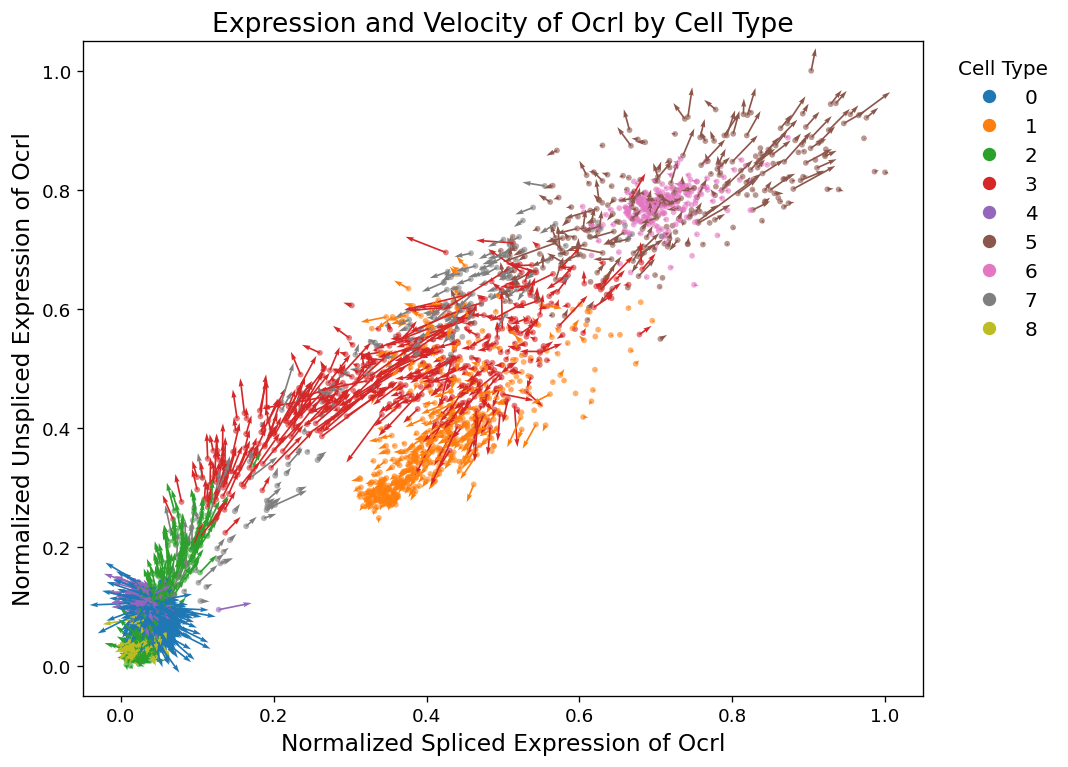

(<Figure size 1080x780 with 1 Axes>,
 <Axes: title={'center': 'Expression and Velocity of Ocrl by Cell Type'}, xlabel='Normalized Spliced Expression of Ocrl', ylabel='Normalized Unspliced Expression of Ocrl'>)

In [78]:
lineagevi.plots.plot_phase_plane(adata,  'Ocrl', cluster_key='leiden', u_scale=.1, s_scale=.1, alpha=1, head_width=0.02, head_length=0.03, length_includes_head=False)


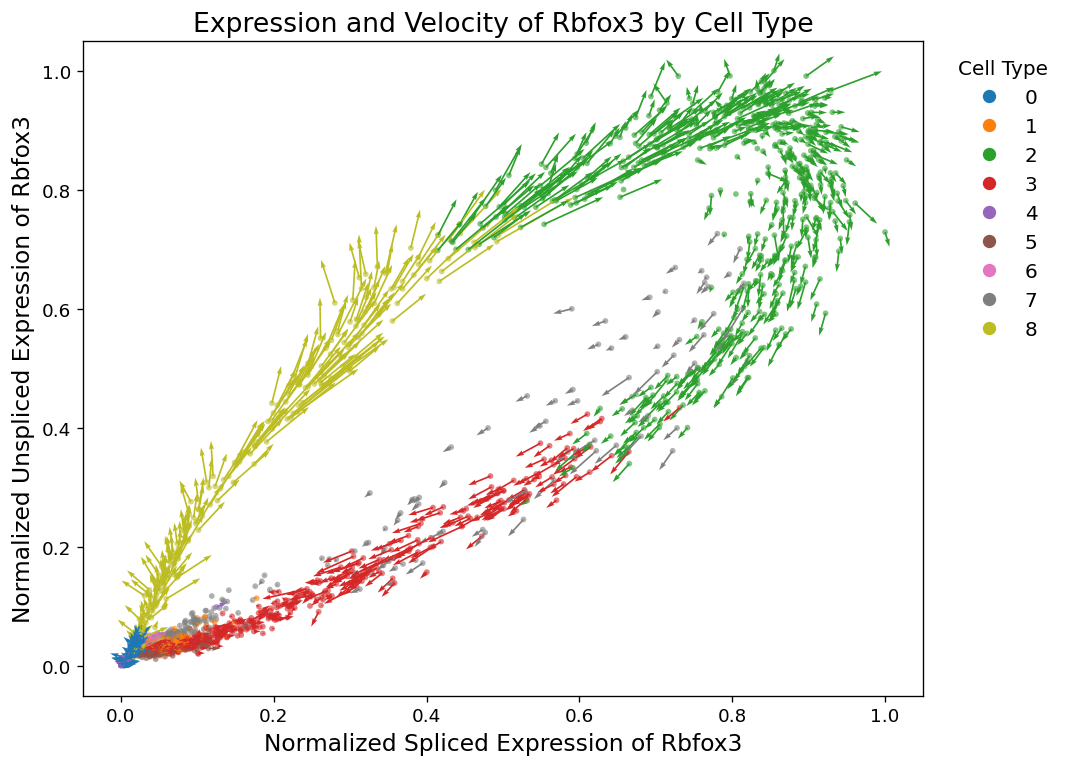

KeyError: "Gene 'Rbfox2' not found in adata.var_names"

In [ ]:
lineagevi.plots.plot_phase_plane(adata,  'Gnas', cluster_key='leiden', u_scale=.1, s_scale=.1, alpha=1, head_width=0.02, head_length=0.03, length_includes_head=False)
lineagevi.plots.plot_phase_plane(adata,  'Rbfox3', cluster_key='leiden', u_scale=.1, s_scale=.1, alpha=1, head_width=0.02, head_length=0.03, length_includes_head=False)
lineagevi.plots.plot_phase_plane(adata,  'Rbfox2', cluster_key='leiden', u_scale=.1, s_scale=.1, alpha=1, head_width=0.02, head_length=0.03, length_includes_head=False)

In [ ]:
adata_gp = lineagevi.utils.build_gp_adata(adata)

computing velocity graph (using 1/64 cores)


  0%|          | 0/3696 [00:00<?, ?cells/s]

    finished (0:00:06) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


/home/lgolinelli/miniconda3/envs/lineagevi/lib/python3.11/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/lgolinelli/miniconda3/envs/lineagevi/lib/python3.11/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/lgolinelli/miniconda3/envs/lineagevi/lib/python3.11/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/lgolinelli/miniconda3/envs/l

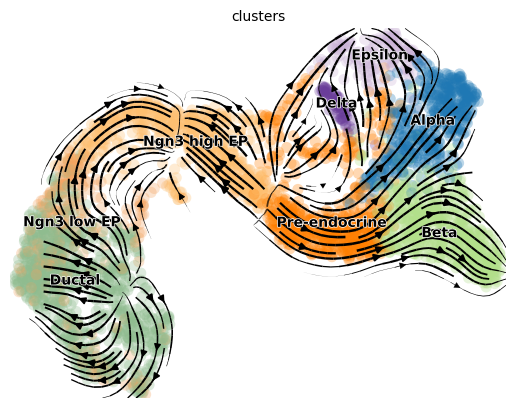

In [17]:
cluster_key='clusters'

sc.pp.neighbors(adata)
sc.tl.umap(adata)
scv.tl.velocity_graph(adata)
scv.pl.velocity_embedding_stream(adata, color=cluster_key)

In [ ]:
adata_gp = lineagevi.utils.build_gp_adata(adata)
sc.pp.neighbors(adata_gp)
sc.tl.umap(adata_gp)
scv.tl.velocity_graph(adata_gp)
scv.pl.velocity_embedding_stream(adata_gp, color=cluster_key)

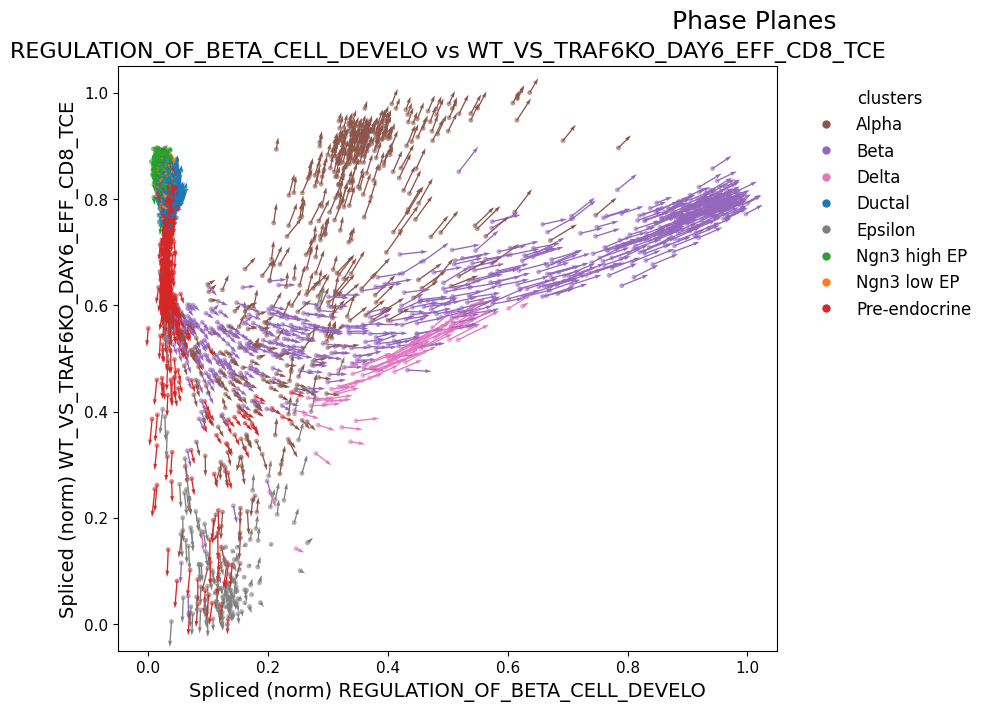

(<Figure size 1400x700 with 2 Axes>,
 array([[<Axes: title={'center': 'REGULATION_OF_BETA_CELL_DEVELO vs WT_VS_TRAF6KO_DAY6_EFF_CD8_TCE'}, xlabel='Spliced (norm) REGULATION_OF_BETA_CELL_DEVELO', ylabel='Spliced (norm) WT_VS_TRAF6KO_DAY6_EFF_CD8_TCE'>,
         <Axes: >]], dtype=object))

In [ ]:
lineagevi.plots.plot_gp_phase_planes(
    adata_gp,
    program_pairs=[('REGULATION_OF_BETA_CELL_DEVELO', 'WT_VS_TRAF6KO_DAY6_EFF_CD8_TCE')],
    cluster_key='clusters',
    title='Phase Planes',
    figsize_per_panel = (7, 7),
    alpha = 1,
    arrow_multiplier=.5
)

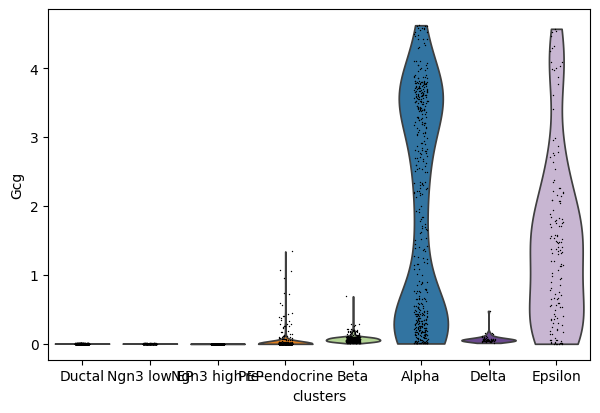

In [ ]:
sc.pl.violin(adata, keys='Gcg', layer='alpha', groupby='clusters')

In [ ]:
vae.model.latent_enrich(adata, groups='clusters', comparison='rest', n_sample=5000, key_added='bf_scores')

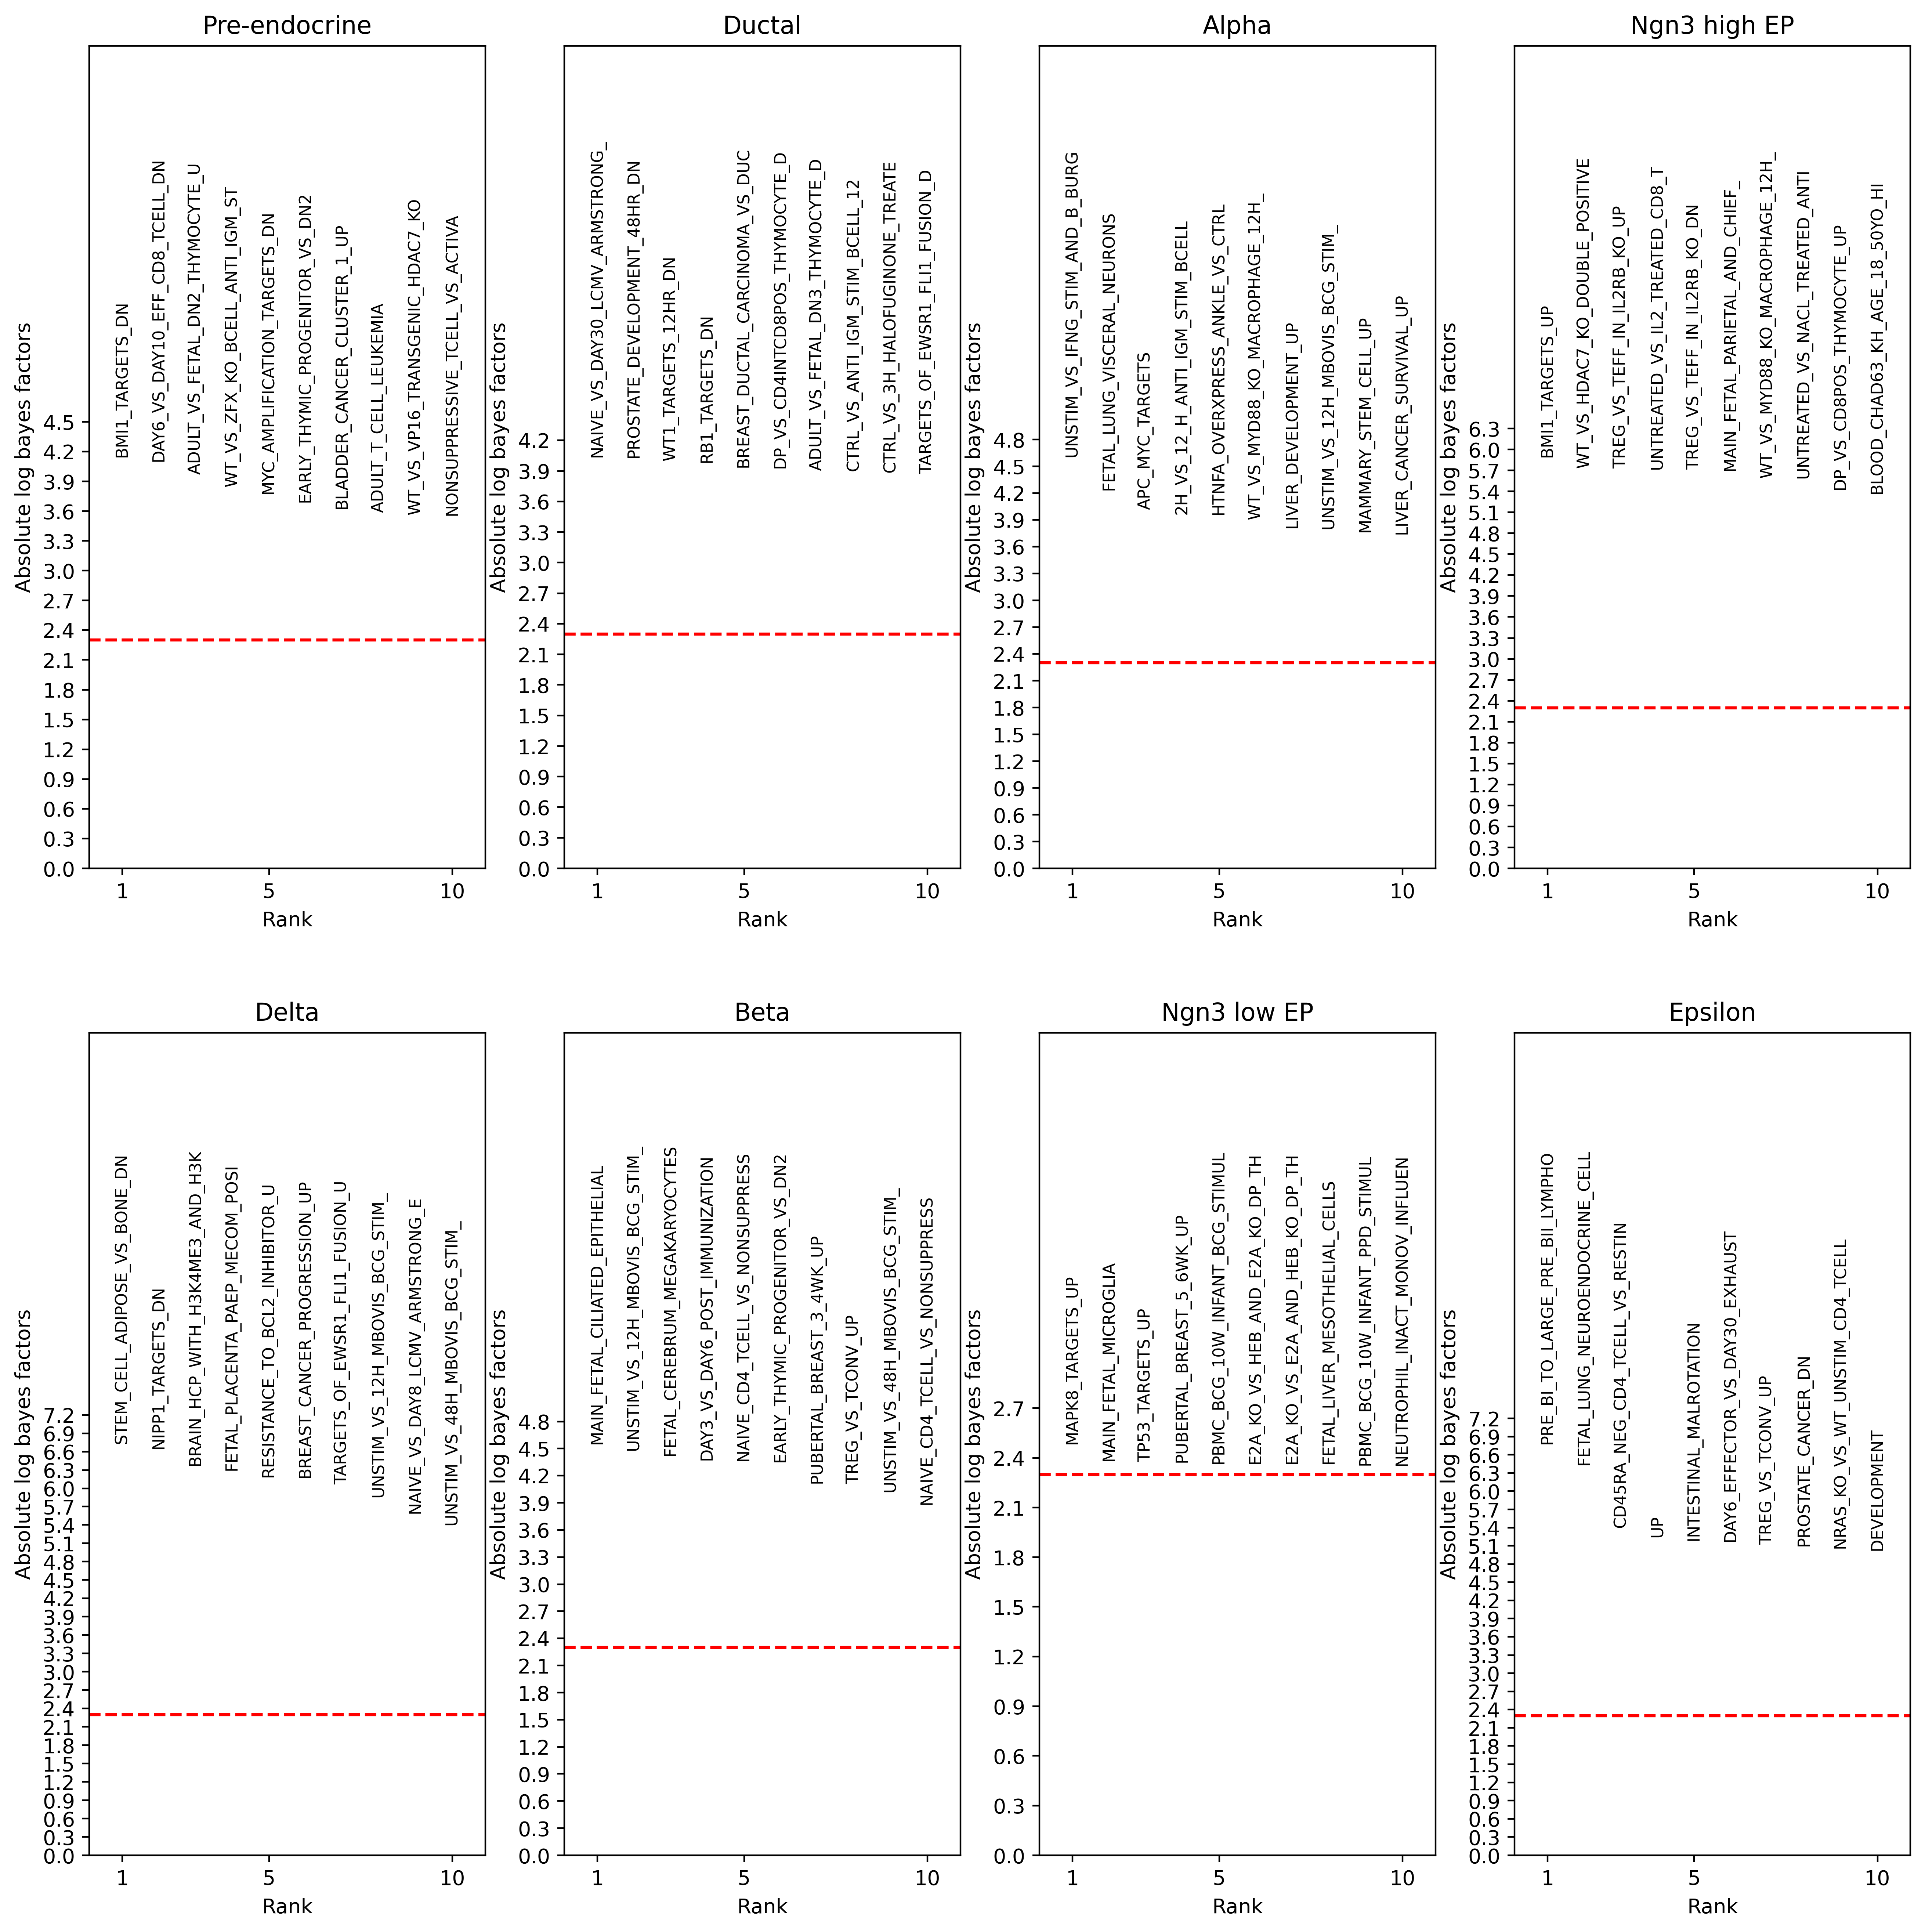

In [ ]:
lineagevi.plots.plot_abs_bfs(adata, scores_key='bf_scores', n_cols=4, n_points=10, lim_val=2.3, fontsize=8, scale_y=2, yt_step=0.3,
                    title=None, figsize=None, dpi=400)

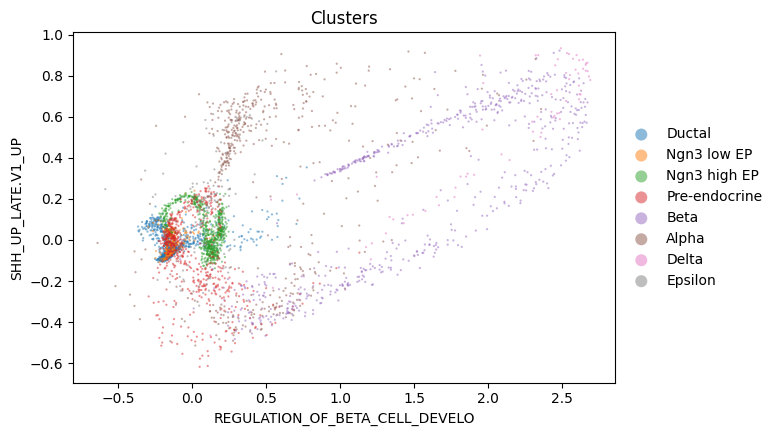

In [ ]:
sc.pl.scatter(adata_gp, x='REGULATION_OF_BETA_CELL_DEVELO',y='SHH_UP_LATE.V1_UP', color='clusters', layers='velocity', size=10, alpha=0.5, title='Clusters')

In [ ]:
df_genes, df_gps, perturbed_outputs = vae.perturb_genes(
                adata=adata,
                groupby_key='clusters',
                group_to_perturb='Beta',
                genes_to_perturb=['Sntg1', 'Snhg6'],
                perturb_value=0,
                perturb_spliced=True,
                perturb_unspliced=True,
            )


In [ ]:
for key, value in perturbed_outputs.items():
    print(key)
    print('---')

recon
---
mean
---
logvar
---
velocity_gp
---
velo_u_pert
---
velo_pert
---
alpha_pert
---
beta_pert
---
gamma_pert
---


In [ ]:
df_genes, df_gps, perturbed_outputs = vae.perturb_gps(
                adata=adata,
                gp_uns_key='terms',
                gps_to_perturb=['YBX1_TARGETS_DN', 'YBX1_TARGETS_UP'],
                groupby_key='clusters',
                group_to_perturb='Beta',
                perturb_value=0,
            )

In [ ]:
df_genes

,genes,velo_diff_u,abs_velo_diff_u,velo_diff_s,abs_velo_diff_s,x_dec_diff,x_dec_diff_abs,alpha_diff,alpha_diff_abs,beta_diff,beta_diff_abs,gamma_diff,gamma_diff_abs
0,Sntg1,0.000096,0.000096,0.004703,0.004703,0.0,0.0,0.004804,0.004804,0.003338,0.003338,0.000181,0.000181
1,Snhg6,0.000204,0.000204,0.000977,0.000977,0.0,0.0,0.000232,0.000232,0.001406,0.001406,-0.004928,0.004928
2,Ncoa2,0.003041,0.003041,-0.000625,0.000625,0.0,0.0,0.002444,0.002444,-0.000835,0.000835,0.000159,0.000159
3,Sbspon,0.000911,0.000911,0.000024,0.000024,0.0,0.0,0.000922,0.000922,0.007502,0.007502,-0.002778,0.002778
4,Pkhd1,-0.001739,0.001739,0.001495,0.001495,0.0,0.0,-0.000162,0.000162,0.007606,0.007606,0.004828,0.004828
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1990,Rbbp7,-0.001171,0.001171,0.000482,0.000482,0.0,0.0,-0.001087,0.001087,0.001416,0.001416,-0.000300,0.000300
1991,Ap1s2,0.001092,0.001092,-0.005774,0.005774,0.0,0.0,-0.002869,0.002869,-0.012246,0.012246,0.007053,0.007053
1992,Gpm6b,-0.000209,0.000209,0.000016,0.000016,0.0,0.0,-0.000184,0.000184,0.004650,0.004650,0.006908,0.006908
1993,Uty,-0.001092,0.001092,0.000477,0.000477,0.0,0.0,-0.000659,0.000659,0.002536,0.002536,-0.001722,0.001722


In [ ]:
df_gps

,gene_programs,velo_gp,abs_velo_gp
0,RESPONSE_TO_LPS_WITH_MECHANICA,0.000885,0.000885
1,YBX1_TARGETS_DN,-0.007186,-0.007186
2,YBX1_TARGETS_UP,-0.009831,-0.009831
3,CD40_SIGNALING_UP,0.012820,0.012820
4,CTNNB1_ONCOGENIC_SIGNATURE,0.004654,0.004654
...,...,...,...
684,HEDGEHOG_SIGNALING_PARACRINE_D,0.001185,0.001185
685,HEDGEHOG_SIGNALING_PARACRINE_U,-0.002561,-0.002561
686,MAPK8_TARGETS_DN,0.014800,0.014800
687,MAPK8_TARGETS_UP,0.011189,0.011189


In [ ]:
for key, value in perturbed_outputs.items():
    print(key)
    print('---')


velocity_gp_pert
---
velo_u_pert
---
velo_pert
---
alpha_pert
---
beta_pert
---
gamma_pert
---
recon
---


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  12 tasks      | elapsed:    3.0s
[Parallel(n_jobs=-1)]: Done 108 tasks      | elapsed:    4.8s
[Parallel(n_jobs=-1)]: Done 268 tasks      | elapsed:    8.0s
[Parallel(n_jobs=-1)]: Done 492 tasks      | elapsed:   12.8s
[Parallel(n_jobs=-1)]: Done 780 tasks      | elapsed:   18.9s
[Parallel(n_jobs=-1)]: Done 1132 tasks      | elapsed:   26.6s
[Parallel(n_jobs=-1)]: Done 1548 tasks      | elapsed:   35.5s
[Parallel(n_jobs=-1)]: Done 2028 tasks      | elapsed:   45.9s
[Parallel(n_jobs=-1)]: Done 2572 tasks      | elapsed:   57.6s
[Parallel(n_jobs=-1)]: Done 3180 tasks      | elapsed:  1.2min


Adding directional_variance to adata.obs
Adding directional_difference to adata.obs
Adding directional_cosine_sim_variance to adata.obs
Adding directional_cosine_sim_difference to adata.obs
Adding directional_cosine_sim_mean to adata.obs
Plotting directional_cosine_sim_variance


[Parallel(n_jobs=-1)]: Done 3696 out of 3696 | elapsed:  1.4min finished


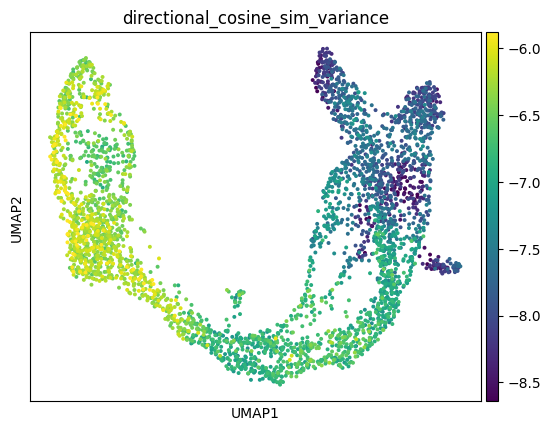

(                  directional_variance  directional_difference  \
 index                                                            
 AAACCTGAGAGGGATA              0.000077                0.025943   
 AAACCTGAGCCTTGAT              0.000132                0.036323   
 AAACCTGAGGCAATTA              0.000026                0.015280   
 AAACCTGCATCATCCC              0.000099                0.030012   
 AAACCTGGTAAGTGGC              0.000135                0.033445   
 ...                                ...                     ...   
 TTTGTCAAGTGACATA              0.000101                0.031284   
 TTTGTCAAGTGTGGCA              0.000128                0.029963   
 TTTGTCAGTTGTTTGG              0.000154                0.040202   
 TTTGTCATCGAATGCT              0.000028                0.016444   
 TTTGTCATCTGTTTGT              0.000092                0.029163   
 
                   directional_cosine_sim_variance  \
 index                                               
 AAACCTGAGAGGGATA  

In [ ]:
'''vae.get_directional_uncertainty(
    adata,
    use_gp_velo = False,
    n_samples = 50,
    n_jobs = -1,
    show_plot =  True,
    base_seed = None,
)

vae.get_directional_uncertainty(
    adata,
    use_gp_velo = False,
    n_samples = 50,
    n_jobs = -1,
    show_plot =  True,
    base_seed = None,
)

df = vae.compute_extrinsic_uncertainty(
    adata,
    use_gp_velo=True,
    n_samples=25, 
    n_jobs=-1,
    show_plot=True)


df = vae.compute_extrinsic_uncertainty(
    adata,
    use_gp_velo=True,
    n_samples=25, 
    n_jobs=-1,
    show_plot=True) '''

In [ ]:
# Single cluster pair alignment (gene expression space)
alignment = vae.compute_cluster_alignment(
    source_cluster='Alpha',
    target_cluster='Beta'
)

# Single cluster pair alignment (GP space)
alignment_gp = vae.compute_cluster_alignment(
    source_cluster='Alpha',
    target_cluster='Beta',
    use_gp_space=True
)

# Full alignment matrix (gene expression space)
matrix, clusters = vae.compute_cluster_alignment_matrix()

# Full alignment matrix with weighted mean aggregation
matrix_weighted, clusters = vae.compute_cluster_alignment_matrix(
    aggregation='weighted_mean'
)

# GP space alignment matrix
matrix_gp, clusters = vae.compute_cluster_alignment_matrix(
    use_gp_space=True
)

In [ ]:
# Compute alignment matrix - returns DataFrame with cluster names as indices
df = vae.compute_cluster_alignment_matrix()

# Access specific alignment using cluster names
alignment_ab = df.loc['Alpha', 'Beta']

# Find which cluster Alpha points toward
target_cluster = df.loc['Alpha'].idxmax()
alignment = df.loc['Alpha', target_cluster]
print(f"Alpha → {target_cluster}: {alignment:.3f}")

# Visualize directly with seaborn (no need to specify labels!)
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(df, cmap='RdBu_r', center=0, annot=True, fmt='.2f')
plt.xlabel('Target Cluster')
plt.ylabel('Source Cluster')
plt.title('Cluster Alignment Matrix')
plt.show()

# Filter or subset easily
# All clusters that Alpha points toward (sorted by alignment)
alpha_targets = df.loc['Alpha'].sort_values(ascending=False)

# All clusters that point toward Beta
sources_to_beta = df.loc[:, 'Beta'].sort_values(ascending=False)

AttributeError: 'tuple' object has no attribute 'loc'

In [ ]:
# This will now work correctly
df = vae.compute_cluster_alignment_matrix()
alignment_ab = df.loc['Alpha', 'Beta']  # ✅ Works!

AttributeError: 'tuple' object has no attribute 'loc'